# Chapter 1: De Rham Theory

**Source Span.** Bott-Tu, *Differential Forms in Algebraic Topology*, Chapter I, printed pages 13-88. In this PDF the printed span is reached at physical PDF pages 24-99; the table of contents and page headers were used only for source orientation.

**Chapter goal.** Turn the first chapter into a computational map of de Rham cohomology: differential forms become a cochain complex, covers become exact linear algebra, orientation makes integration meaningful, compact support reverses the local calculation, and Thom/Poincare duality packages integration along normal directions.

The notebook is standalone. It does not reproduce textbook figures or prose. Instead it builds small models whose checks mirror the chapter's proof moves: `d^2 = 0`, Mayer-Vietoris exactness, Stokes' theorem, compact-support obstruction by total integral, the Five-Lemma propagation pattern, the Thom class fiber integral, and the nonorientable repair by twisted coefficients or densities.


## Visual Storyboard And Translation Guide

The chapter has seven source sections, and each section is routed to one inspectable object.

| Source section | Computational translation | Visual or check |
| --- | --- | --- |
| 1. The de Rham complex on `R^n` | Forms are degree-indexed coefficient arrays; `d` is a signed derivative operator. | SymPy verifies `d^2 = 0` and a punctured-plane angular form is closed but has nonzero period. |
| 2. Mayer-Vietoris | A two-open-set cover gives a short exact problem in vector spaces. | A cover of `S^1` has two overlap components, and the quotient of overlap constants detects `H^1(S^1)`. |
| 3. Orientation and integration | Orientation is the sign convention that makes boundary and volume integrals agree. | A triangle checks `int_boundary x dy = int_triangle dx wedge dy`. |
| 4. Poincare lemmas | Contractible ordinary cohomology collapses, while compact-support cohomology sees total mass. | Two bump forms on `R` show why zero total integral is exact with compact support and mass one is not. |
| 5. Mayer-Vietoris argument | Local calculations propagate across a finite good cover. | A dependency graph makes the proof machine visible; a torus band realizes a Poincare dual form. |
| 6. Thom isomorphism | A Thom class is the compact-vertical form whose fiber integral is one. | A Plotly tube shows a normalized vertical bump on fiber disks and checks the projection formula numerically. |
| 7. Nonorientable case | The orientation line has sign holonomy; densities/twisted forms remove the global sign obstruction. | A Mobius strip records the orientation flip and compares it with the cylinder. |

**Library Routing.** SymPy is used where exact exterior-derivative identities are the lesson. Matplotlib is used for durable 2D diagrams where scale, orientation, and support are the teaching target. NetworkX is used only for the Mayer-Vietoris/Five-Lemma dependency graph. Plotly is used for the vector-bundle and Mobius-strip geometry because rotating the object is more informative than a static projection. Pandas/CSV and JSON record the checks so the final sanity cell can audit the artifacts without trusting the picture.


In [1]:
from pathlib import Path
import sys
import math
import json
import warnings

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
import plotly.graph_objects as go
from scipy.integrate import cumulative_trapezoid


def find_book_root(start: Path | None = None) -> Path:
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate Differential-Forms-in-Algebraic-Topology book root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (  # noqa: E402
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-01-de-rham-theory"
UNIT_TITLE = "De Rham Theory"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
GENERATED_ARTIFACTS: list[Path] = []

plt.rcParams.update({
    "figure.figsize": (7.5, 5.0),
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

routing_rows = [
    {
        "concept": "de Rham differential and periods",
        "representation": "symbolic coefficients plus punctured-plane field",
        "libraries": "SymPy, Matplotlib",
        "why": "exact identities need symbolic derivatives; periods need a visible loop",
        "artifact_or_check": "de-rham-complex-symbolic-checks.json; de-rham-complex-angular-form.png",
    },
    {
        "concept": "Mayer-Vietoris exactness",
        "representation": "finite-dimensional cover model for S1",
        "libraries": "NumPy, Matplotlib",
        "why": "exactness is a rank/kernel calculation tied to a cover picture",
        "artifact_or_check": "mayer-vietoris-s1-exactness.json; mayer-vietoris-circle-cover.png",
    },
    {
        "concept": "orientation, integration, Stokes",
        "representation": "oriented triangle with boundary integral",
        "libraries": "SymPy, Matplotlib",
        "why": "the sign convention is geometric and the integral is exact",
        "artifact_or_check": "orientation-stokes-checks.json; orientation-stokes-triangle.png",
    },
    {
        "concept": "compact-support Poincare lemma",
        "representation": "bump form and cumulative primitive on R",
        "libraries": "SciPy, Matplotlib",
        "why": "support and total mass are easiest to inspect as graphs",
        "artifact_or_check": "poincare-compact-support-checks.json; poincare-compact-support-bump.png",
    },
    {
        "concept": "MV argument and Poincare duality",
        "representation": "proof dependency graph and torus fundamental square",
        "libraries": "NetworkX, Matplotlib",
        "why": "the proof propagates by dependencies; dual forms localize in a tubular band",
        "artifact_or_check": "mv-argument-duality-dependency-graph.png; poincare-dual-torus-band.png",
    },
    {
        "concept": "Thom class and fiber integration",
        "representation": "fiber disks over a base circle with normalized vertical bump",
        "libraries": "Plotly, NumPy",
        "why": "the total space is geometric and benefits from 3D rotation",
        "artifact_or_check": "thom-fiber-integration-tube.html; thom-fiber-integration-checks.json",
    },
    {
        "concept": "nonorientable orientation local system",
        "representation": "Mobius strip and holonomy sign check",
        "libraries": "Plotly, NumPy",
        "why": "a one-circuit frame flip is spatial, not just algebraic",
        "artifact_or_check": "nonorientable-mobius-local-system.html; nonorientable-local-system-checks.json",
    },
]

routing_path = save_csv(routing_rows, TABLES / "chapter-01-library-routing.csv")
GENERATED_ARTIFACTS.append(routing_path)
display_artifact(routing_path)


[chapter-01-library-routing.csv](D:/Geometry/Differential-Forms-in-Algebraic-Topology/artifacts/chapter-01-de-rham-theory/tables/chapter-01-library-routing.csv)

## 1. The de Rham Complex On Euclidean Space

A differential form can be read as a degree-labeled measurement device. A `0`-form is a function, a `1`-form measures directed curves, and a `2`-form measures oriented area. The exterior derivative raises degree by one and is designed so that applying it twice gives zero. That single identity turns forms into a cochain complex, so closed forms can be compared modulo exact forms.

The first check below uses exact symbolic derivatives in two variables. The second check uses the angular form on the punctured plane. It is closed away from the origin, so the local derivative test cannot see a problem; its integral around a loop is nonzero, so it cannot be globally exact on the punctured plane. This is the smallest visual warning that the Poincare lemma requires a contractible or star-shaped hypothesis.


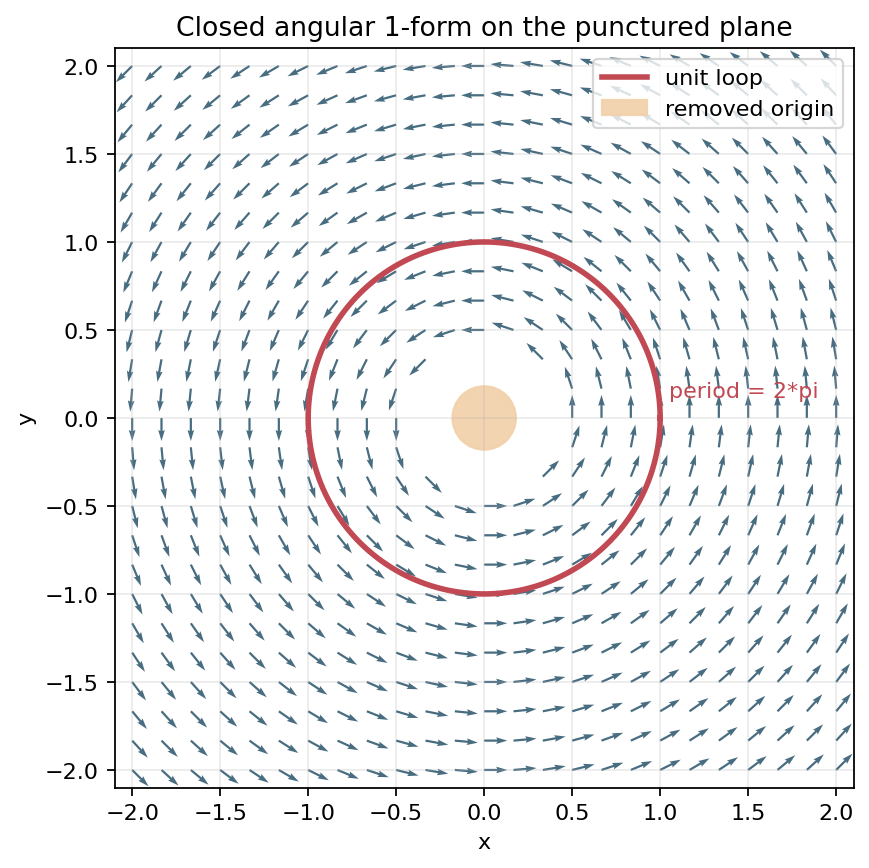

`de-rham-complex-symbolic-checks.json`

{'d_squared_zero_for_function': True,
 'antiderivation_identity': True,
 'sample_one_form_exterior_derivative': '-sin(x)',
 'angular_form_closed_on_punctured_plane': True,
 'angular_circle_integrand': '1',
 'angular_period': '2*pi',
 'angular_period_over_2pi': 1.0}

In [2]:
x, y, t = sp.symbols("x y t", real=True)
f = x**2 * y + sp.sin(x * y)
P = x * y**2
Q = sp.cos(x) + x**2 * y

df = (sp.diff(f, x), sp.diff(f, y))
d_df = sp.simplify(sp.diff(df[1], x) - sp.diff(df[0], y))
d_alpha = sp.simplify(sp.diff(Q, x) - sp.diff(P, y))
left_antiderivation = sp.simplify(sp.diff(f * Q, x) - sp.diff(f * P, y))
df_wedge_alpha = sp.diff(f, x) * Q - sp.diff(f, y) * P
right_antiderivation = sp.simplify(df_wedge_alpha + f * d_alpha)

angular_P = -y / (x**2 + y**2)
angular_Q = x / (x**2 + y**2)
angular_closed = sp.simplify(sp.diff(angular_Q, x) - sp.diff(angular_P, y))
circle_x = sp.cos(t)
circle_y = sp.sin(t)
circle_integrand = sp.simplify(
    angular_P.subs({x: circle_x, y: circle_y}) * sp.diff(circle_x, t)
    + angular_Q.subs({x: circle_x, y: circle_y}) * sp.diff(circle_y, t)
)
angular_period = sp.integrate(circle_integrand, (t, 0, 2 * sp.pi))

xs = np.linspace(-2.0, 2.0, 25)
ys = np.linspace(-2.0, 2.0, 25)
X, Y = np.meshgrid(xs, ys)
R2 = X**2 + Y**2
mask = R2 > 0.18
U = np.divide(-Y, R2, out=np.zeros_like(X), where=mask)
V = np.divide(X, R2, out=np.zeros_like(Y), where=mask)
scale = np.sqrt(U**2 + V**2)
U_plot = np.divide(U, scale, out=np.zeros_like(U), where=scale > 0)
V_plot = np.divide(V, scale, out=np.zeros_like(V), where=scale > 0)

theta = np.linspace(0, 2 * np.pi, 400)
fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.quiver(X[mask], Y[mask], U_plot[mask], V_plot[mask], scale=32, width=0.003, color="#28536b", alpha=0.85)
ax.plot(np.cos(theta), np.sin(theta), color="#c14953", linewidth=2.5, label="unit loop")
ax.add_patch(patches.Circle((0, 0), 0.18, color="#f2d0a9", alpha=0.9, label="removed origin"))
ax.text(1.05, 0.12, "period = 2*pi", color="#c14953")
ax.set_title("Closed angular 1-form on the punctured plane")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-2.1, 2.1)
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
angular_fig_path = save_matplotlib(fig, FIGURES / "de-rham-complex-angular-form.png")
plt.close(fig)

symbolic_report = {
    "d_squared_zero_for_function": bool(d_df == 0),
    "antiderivation_identity": bool(sp.simplify(left_antiderivation - right_antiderivation) == 0),
    "sample_one_form_exterior_derivative": str(d_alpha),
    "angular_form_closed_on_punctured_plane": bool(angular_closed == 0),
    "angular_circle_integrand": str(circle_integrand),
    "angular_period": str(angular_period),
    "angular_period_over_2pi": float(sp.N(angular_period / (2 * sp.pi))),
}
symbolic_path = save_json(symbolic_report, CHECKS / "de-rham-complex-symbolic-checks.json")
GENERATED_ARTIFACTS.extend([angular_fig_path, symbolic_path])

display_artifact(angular_fig_path, width=760)
display_artifact(symbolic_path)
symbolic_report


## 2. Mayer-Vietoris As Exact Linear Algebra

The Mayer-Vietoris sequence is the chapter's first major computational engine. For a cover `X = U union V`, forms restrict to `U`, `V`, and `U cap V`; a partition of unity supplies the connecting map that repairs overcounting on the overlap.

A cover of the circle by two contractible arcs is already enough to show the mechanism. The sets `U` and `V` have one connected component each, but their intersection has two connected components. Constants on the two overlap components form `R^2`; the image of constants from `U` and `V` is only the diagonal line. The missing quotient direction is exactly one-dimensional, matching `H^1(S^1)`.


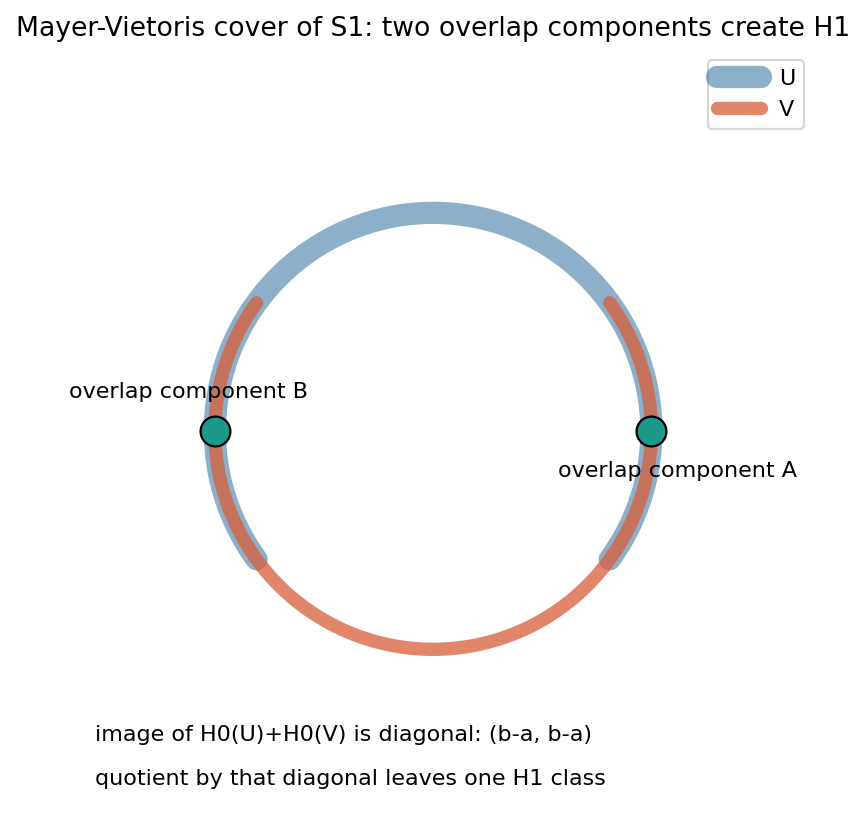

`mayer-vietoris-s1-exactness.json`

{'B_after_A_zero': True,
 'C_after_B_zero': True,
 'rank_A': 1,
 'rank_B': 1,
 'rank_C': 1,
 'kernel_B_dimension': 1,
 'kernel_C_dimension': 1,
 'image_A_dimension': 1,
 'image_B_dimension': 1,
 'exact_at_H0_U_plus_V': True,
 'exact_at_H0_overlap': True,
 'computed_H1_S1_dimension': 1}

In [3]:
A = np.array([[1.0], [1.0]])
B = np.array([[-1.0, 1.0], [-1.0, 1.0]])
C = np.array([[1.0, -1.0]])
rank = np.linalg.matrix_rank
mv_report = {
    "B_after_A_zero": bool(np.allclose(B @ A, 0)),
    "C_after_B_zero": bool(np.allclose(C @ B, 0)),
    "rank_A": int(rank(A)),
    "rank_B": int(rank(B)),
    "rank_C": int(rank(C)),
    "kernel_B_dimension": int(2 - rank(B)),
    "kernel_C_dimension": int(2 - rank(C)),
    "image_A_dimension": int(rank(A)),
    "image_B_dimension": int(rank(B)),
    "exact_at_H0_U_plus_V": bool(rank(A) == 2 - rank(B)),
    "exact_at_H0_overlap": bool(rank(B) == 2 - rank(C)),
    "computed_H1_S1_dimension": int(2 - rank(B)),
}

fig, ax = plt.subplots(figsize=(7.8, 6.2))
theta_u = np.linspace(-0.20 * np.pi, 1.20 * np.pi, 300)
theta_v = np.linspace(0.80 * np.pi, 2.20 * np.pi, 300)
ax.plot(np.cos(theta_u), np.sin(theta_u), color="#2f6f9f", linewidth=10, alpha=0.55, solid_capstyle="round", label="U")
ax.plot(np.cos(theta_v), np.sin(theta_v), color="#d95d39", linewidth=6, alpha=0.75, solid_capstyle="round", label="V")
for angle, label, dy in [(0.0, "overlap component A", -0.18), (np.pi, "overlap component B", 0.18)]:
    ax.scatter([np.cos(angle)], [np.sin(angle)], s=180, color="#1b998b", edgecolor="black", zorder=5)
    ax.text(1.12 * np.cos(angle), 1.12 * np.sin(angle) + dy, label, ha="center", va="center")
ax.text(-1.55, -1.42, "image of H0(U)+H0(V) is diagonal: (b-a, b-a)", fontsize=10)
ax.text(-1.55, -1.62, "quotient by that diagonal leaves one H1 class", fontsize=10)
ax.set_title("Mayer-Vietoris cover of S1: two overlap components create H1")
ax.set_aspect("equal")
ax.set_xlim(-1.75, 1.75)
ax.set_ylim(-1.75, 1.75)
ax.axis("off")
ax.legend(loc="upper right")
mv_fig_path = save_matplotlib(fig, FIGURES / "mayer-vietoris-circle-cover.png")
plt.close(fig)

mv_path = save_json(mv_report, CHECKS / "mayer-vietoris-s1-exactness.json")
GENERATED_ARTIFACTS.extend([mv_fig_path, mv_path])

display_artifact(mv_fig_path, width=760)
display_artifact(mv_path)
mv_report


## 3. Orientation, Integration, And Stokes' Theorem

Integration of a top-degree form is not just area with units attached; it depends on choosing which ordered frames are positive. Stokes' theorem is the consistency condition: the integral of `d omega` over an oriented region equals the integral of `omega` over the induced oriented boundary.

The triangle below uses `omega = x dy`. Its derivative is `dx wedge dy`, so the interior integral is ordinary signed area. Reversing the boundary orientation flips the sign, which is exactly the behavior needed later when pairings and Poincare duality are defined by integration.


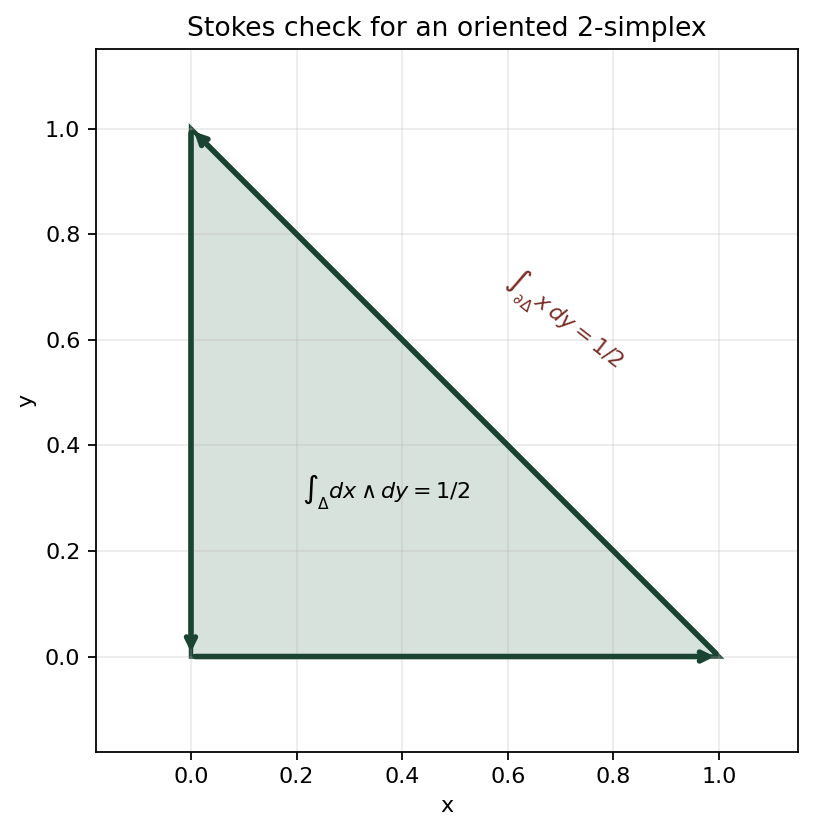

`orientation-stokes-checks.json`

{'form': 'omega = x dy',
 'd_omega': 'dx wedge dy',
 'boundary_terms': ['0', '1/2', '0'],
 'boundary_integral': '1/2',
 'interior_integral': '1/2',
 'stokes_residual': '0',
 'reversed_boundary_integral': '-1/2'}

In [4]:
s = sp.symbols("s", real=True)
segments = [
    (s, 0),
    (1 - s, s),
    (0, 1 - s),
]
boundary_terms = [sp.integrate(x_s * sp.diff(y_s, s), (s, 0, 1)) for x_s, y_s in segments]
boundary_integral = sp.simplify(sum(boundary_terms))
area_integral = sp.Rational(1, 2)
stokes_residual = sp.simplify(boundary_integral - area_integral)

fig, ax = plt.subplots(figsize=(7.0, 5.7))
triangle = np.array([[0, 0], [1, 0], [0, 1]])
ax.add_patch(patches.Polygon(triangle, closed=True, facecolor="#d8e2dc", edgecolor="#1b4332", linewidth=2.0))
for start, end in [((0, 0), (1, 0)), ((1, 0), (0, 1)), ((0, 1), (0, 0))]:
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", color="#1b4332", linewidth=2.5))
ax.text(0.37, 0.30, r"$\int_\Delta dx\wedge dy = 1/2$", ha="center")
ax.text(0.58, 0.55, r"$\int_{\partial\Delta} x\,dy = 1/2$", rotation=-38, color="#7b2d26")
ax.set_title("Stokes check for an oriented 2-simplex")
ax.set_xlim(-0.18, 1.15)
ax.set_ylim(-0.18, 1.15)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.25)
stokes_fig_path = save_matplotlib(fig, FIGURES / "orientation-stokes-triangle.png")
plt.close(fig)

stokes_report = {
    "form": "omega = x dy",
    "d_omega": "dx wedge dy",
    "boundary_terms": [str(term) for term in boundary_terms],
    "boundary_integral": str(boundary_integral),
    "interior_integral": str(area_integral),
    "stokes_residual": str(stokes_residual),
    "reversed_boundary_integral": str(-boundary_integral),
}
stokes_path = save_json(stokes_report, CHECKS / "orientation-stokes-checks.json")
GENERATED_ARTIFACTS.extend([stokes_fig_path, stokes_path])

display_artifact(stokes_fig_path, width=720)
display_artifact(stokes_path)
stokes_report


## 4. Ordinary And Compact-Support Poincare Lemmas

The ordinary Poincare lemma says that the de Rham cohomology of a contractible Euclidean model has no positive-degree classes. The compact-support version is deliberately different. On the real line, a compactly supported `1`-form `g(x) dx` has a compactly supported primitive exactly when its total integral is zero. A mass-one bump therefore represents the generator of `H_c^1(R)`.

The figure below makes the obstruction visible. The cumulative primitive of a mass-one bump ends at one, so it cannot vanish at both ends. The cumulative primitive of a zero-mass form returns to zero, so it can be compactly supported after smoothing at the edge of its support.


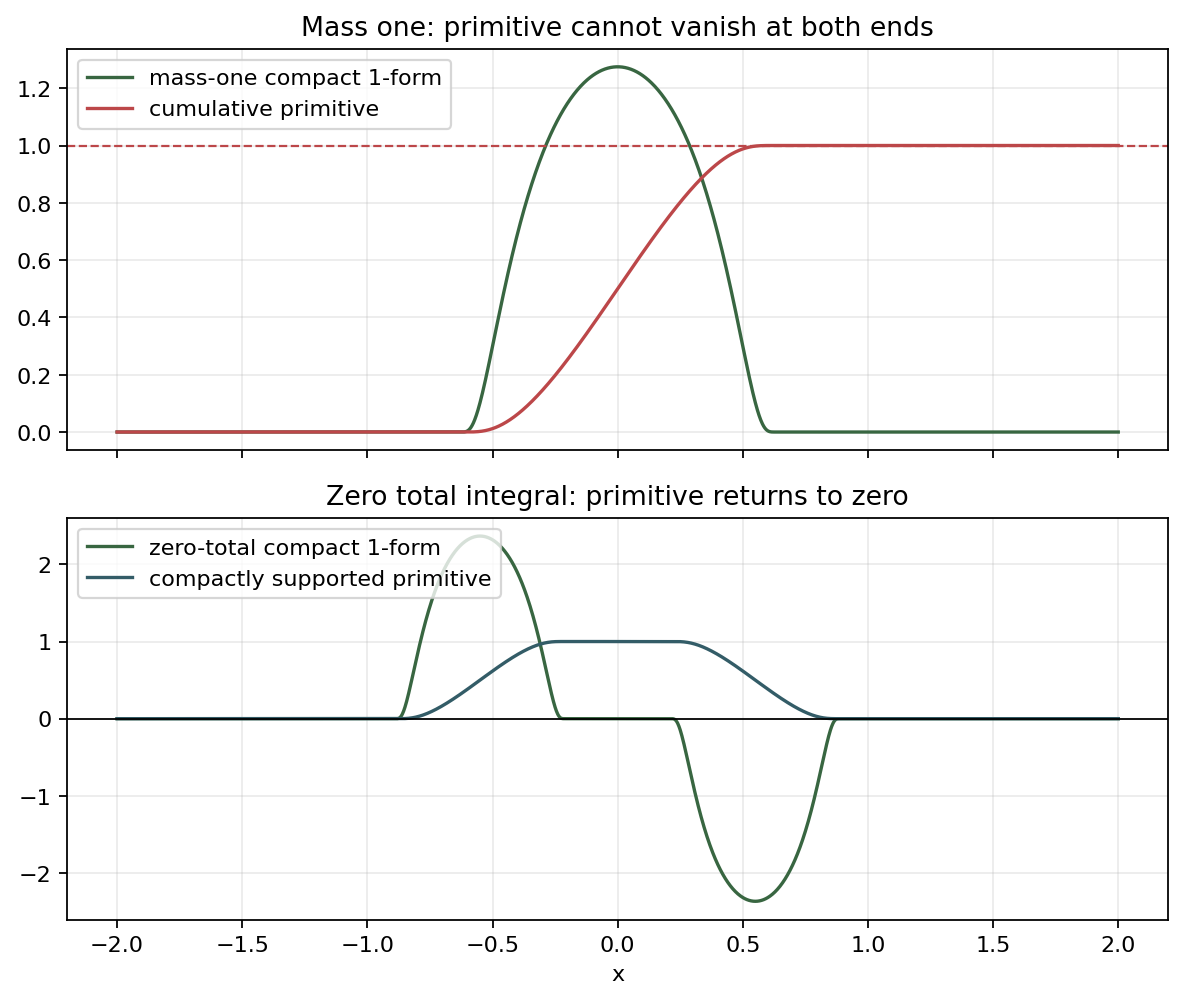

`poincare-compact-support-checks.json`

{'mass_one_integral': 1.0,
 'mass_one_primitive_left': 0.0,
 'mass_one_primitive_right': 0.9999999999999992,
 'zero_mass_integral': -2.220446049250313e-16,
 'zero_mass_primitive_left': 0.0,
 'zero_mass_primitive_right': -1.405277389654506e-16,
 'compact_support_obstruction': 'total integral'}

In [5]:
def standard_bump(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    out = np.zeros_like(z)
    inside = np.abs(z) < 1.0
    out[inside] = np.exp(-1.0 / (1.0 - z[inside] ** 2))
    return out


x_grid = np.linspace(-2.0, 2.0, 2401)
base_grid = np.linspace(-1.0, 1.0, 2001)
base_mass = np.trapezoid(standard_bump(base_grid), base_grid)


def normalized_bump(grid: np.ndarray, center: float, radius: float) -> np.ndarray:
    return standard_bump((grid - center) / radius) / (radius * base_mass)


mass_one = normalized_bump(x_grid, 0.0, 0.65)
zero_mass = normalized_bump(x_grid, -0.55, 0.35) - normalized_bump(x_grid, 0.55, 0.35)
primitive_mass_one = cumulative_trapezoid(mass_one, x_grid, initial=0.0)
primitive_zero_mass = cumulative_trapezoid(zero_mass, x_grid, initial=0.0)

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6.4), sharex=True)
axes[0].plot(x_grid, mass_one, color="#386641", label="mass-one compact 1-form")
axes[0].plot(x_grid, primitive_mass_one, color="#bc4749", label="cumulative primitive")
axes[0].axhline(1.0, color="#bc4749", linestyle="--", linewidth=1.0)
axes[0].set_title("Mass one: primitive cannot vanish at both ends")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.25)
axes[1].plot(x_grid, zero_mass, color="#386641", label="zero-total compact 1-form")
axes[1].plot(x_grid, primitive_zero_mass, color="#335c67", label="compactly supported primitive")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Zero total integral: primitive returns to zero")
axes[1].set_xlabel("x")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.25)
fig.tight_layout()
poincare_fig_path = save_matplotlib(fig, FIGURES / "poincare-compact-support-bump.png")
plt.close(fig)

poincare_report = {
    "mass_one_integral": float(np.trapezoid(mass_one, x_grid)),
    "mass_one_primitive_left": float(primitive_mass_one[0]),
    "mass_one_primitive_right": float(primitive_mass_one[-1]),
    "zero_mass_integral": float(np.trapezoid(zero_mass, x_grid)),
    "zero_mass_primitive_left": float(primitive_zero_mass[0]),
    "zero_mass_primitive_right": float(primitive_zero_mass[-1]),
    "compact_support_obstruction": "total integral",
}
poincare_path = save_json(poincare_report, CHECKS / "poincare-compact-support-checks.json")
GENERATED_ARTIFACTS.extend([poincare_fig_path, poincare_path])

display_artifact(poincare_fig_path, width=760)
display_artifact(poincare_path)
poincare_report


## 5. The Mayer-Vietoris Argument And Poincare Duality

The source's Mayer-Vietoris argument is not just a way to compute a single circle. It is a propagation principle: prove a statement on contractible pieces, prove it is compatible with the two Mayer-Vietoris sequences, and then use a finite good cover to move from local to global. Poincare duality for orientable finite-type manifolds follows this pattern.

The dependency graph records the proof state rather than a decorative concept map. Each arrow means that a later theorem needs the earlier mechanism. The graph also shows why compact supports must be carried along: duality pairs ordinary classes with compactly supported complementary-degree classes through integration.


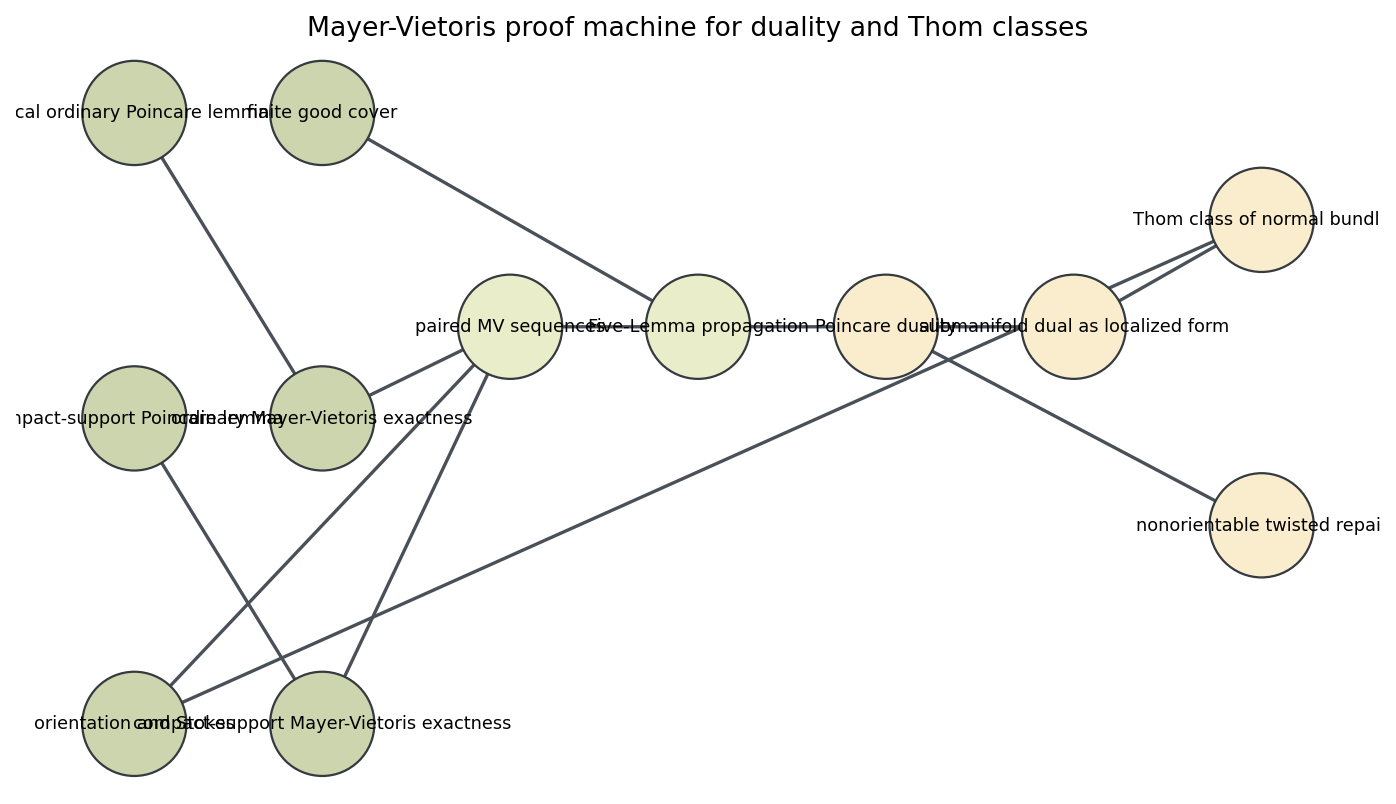

`mv-argument-duality-dependency-graph.json`

{'node_count': 12,
 'edge_count': 12,
 'acyclic': True,
 'topological_order': ['local ordinary Poincare lemma',
  'compact-support Poincare lemma',
  'orientation and Stokes',
  'finite good cover',
  'ordinary Mayer-Vietoris exactness',
  'compact-support Mayer-Vietoris exactness',
  'paired MV sequences',
  'Five-Lemma propagation',
  'Poincare duality',
  'submanifold dual as localized form',
  'nonorientable twisted repair',
  'Thom class of normal bundle'],
 'source_span_role': 'Sections 4-6 use local Poincare lemmas plus Mayer-Vietoris compatibility to propagate finite-good-cover statements.'}

In [6]:
proof_nodes = {
    "local ordinary Poincare lemma": 0,
    "compact-support Poincare lemma": 0,
    "orientation and Stokes": 0,
    "finite good cover": 1,
    "ordinary Mayer-Vietoris exactness": 1,
    "compact-support Mayer-Vietoris exactness": 1,
    "paired MV sequences": 2,
    "Five-Lemma propagation": 3,
    "Poincare duality": 4,
    "submanifold dual as localized form": 5,
    "Thom class of normal bundle": 6,
    "nonorientable twisted repair": 6,
}
proof_edges = [
    ("local ordinary Poincare lemma", "ordinary Mayer-Vietoris exactness"),
    ("compact-support Poincare lemma", "compact-support Mayer-Vietoris exactness"),
    ("finite good cover", "Five-Lemma propagation"),
    ("ordinary Mayer-Vietoris exactness", "paired MV sequences"),
    ("compact-support Mayer-Vietoris exactness", "paired MV sequences"),
    ("orientation and Stokes", "paired MV sequences"),
    ("paired MV sequences", "Five-Lemma propagation"),
    ("Five-Lemma propagation", "Poincare duality"),
    ("Poincare duality", "submanifold dual as localized form"),
    ("submanifold dual as localized form", "Thom class of normal bundle"),
    ("orientation and Stokes", "Thom class of normal bundle"),
    ("Poincare duality", "nonorientable twisted repair"),
]
G = nx.DiGraph()
for node, layer in proof_nodes.items():
    G.add_node(node, layer=layer)
G.add_edges_from(proof_edges)
pos = {}
for layer in sorted(set(proof_nodes.values())):
    layer_nodes = [node for node, node_layer in proof_nodes.items() if node_layer == layer]
    for j, node in enumerate(layer_nodes):
        pos[node] = (layer, -j + 0.35 * (len(layer_nodes) - 1))

fig, ax = plt.subplots(figsize=(11.0, 6.0))
colors = ["#ccd5ae" if proof_nodes[n] <= 1 else "#e9edc9" if proof_nodes[n] <= 3 else "#faedcd" for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle="-|>", arrowsize=16, width=1.5, edge_color="#495057")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, edgecolors="#343a40", node_size=2200)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Mayer-Vietoris proof machine for duality and Thom classes")
ax.axis("off")
proof_fig_path = save_matplotlib(fig, FIGURES / "mv-argument-duality-dependency-graph.png")
plt.close(fig)

proof_report = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "acyclic": bool(nx.is_directed_acyclic_graph(G)),
    "topological_order": list(nx.topological_sort(G)),
    "source_span_role": "Sections 4-6 use local Poincare lemmas plus Mayer-Vietoris compatibility to propagate finite-good-cover statements.",
}
proof_path = save_json(proof_report, CHECKS / "mv-argument-duality-dependency-graph.json")
GENERATED_ARTIFACTS.extend([proof_fig_path, proof_path])

display_artifact(proof_fig_path, width=980)
display_artifact(proof_path)
proof_report


### Poincare Dual As A Localized Form

A Poincare dual class is a cohomology class that turns integration over a submanifold into integration over the ambient manifold. In a square model of the torus, the vertical circle `x = 1/2` has a normal direction in the `x` coordinate. A bump form `rho(x) dx`, supported in a narrow band around that circle and normalized to total integral one in the normal direction, is the model Poincare dual.

The two test loops expose the meaning. A horizontal loop crosses the vertical circle once and integrates the bump to one. A vertical loop has `dx = 0`, so it sees zero. This is the concrete form-level shadow of intersection pairing.


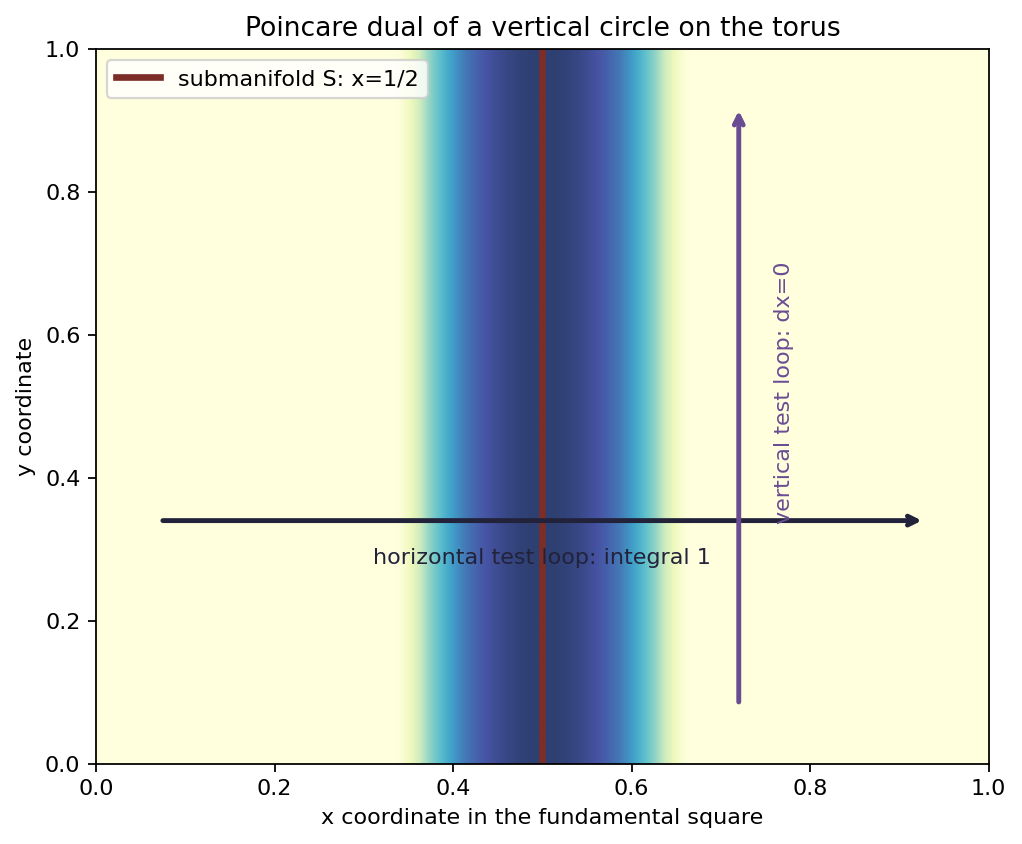

`poincare-dual-torus-band.json`

{'submanifold': 'vertical circle x=1/2 in the torus square model',
 'dual_form_model': 'rho(x) dx with integral rho dx = 1',
 'support_radius': 0.18,
 'horizontal_loop_integral': 1.0,
 'vertical_loop_integral': 0.0,
 'expected_horizontal_intersection_number': 1,
 'expected_vertical_intersection_number': 0}

In [7]:
x_line = np.linspace(0.0, 1.0, 2001)
rho_x = normalized_bump(x_line, 0.5, 0.18)
horizontal_integral = float(np.trapezoid(rho_x, x_line))
vertical_integral = 0.0

fig, ax = plt.subplots(figsize=(7.2, 5.8))
band = np.tile(rho_x, (220, 1))
ax.imshow(band, extent=[0, 1, 0, 1], origin="lower", cmap="YlGnBu", alpha=0.85, aspect="auto")
ax.axvline(0.5, color="#7b2d26", linewidth=3.0, label="submanifold S: x=1/2")
ax.annotate("", xy=(0.93, 0.34), xytext=(0.07, 0.34), arrowprops=dict(arrowstyle="->", linewidth=2.2, color="#22223b"))
ax.text(0.50, 0.28, "horizontal test loop: integral 1", ha="center", color="#22223b")
ax.annotate("", xy=(0.72, 0.92), xytext=(0.72, 0.08), arrowprops=dict(arrowstyle="->", linewidth=2.2, color="#6a4c93"))
ax.text(0.76, 0.52, "vertical test loop: dx=0", rotation=90, va="center", color="#6a4c93")
ax.set_title("Poincare dual of a vertical circle on the torus")
ax.set_xlabel("x coordinate in the fundamental square")
ax.set_ylabel("y coordinate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
pd_fig_path = save_matplotlib(fig, FIGURES / "poincare-dual-torus-band.png")
plt.close(fig)

pd_report = {
    "submanifold": "vertical circle x=1/2 in the torus square model",
    "dual_form_model": "rho(x) dx with integral rho dx = 1",
    "support_radius": 0.18,
    "horizontal_loop_integral": horizontal_integral,
    "vertical_loop_integral": vertical_integral,
    "expected_horizontal_intersection_number": 1,
    "expected_vertical_intersection_number": 0,
}
pd_path = save_json(pd_report, CHECKS / "poincare-dual-torus-band.json")
GENERATED_ARTIFACTS.extend([pd_fig_path, pd_path])

display_artifact(pd_fig_path, width=760)
display_artifact(pd_path)
pd_report


## 6. Thom Isomorphism And Fiber Integration

For an oriented rank `n` vector bundle, the Thom class is a compact-vertical `n`-form whose integral over each fiber is one. Wedge with the Thom class shifts cohomological degree by `n`, while integration along the fiber is the inverse operation. The projection formula says that pulling a form from the base and then integrating along the fiber simply returns the base form multiplied by the fiber integral.

The model below is the trivial oriented rank-2 bundle over a circle. Each displayed disk is a fiber. The color is a normalized radial bump on the fiber, serving as a numerical Thom-form model. The check records that the fiber mass is nearly one and that the projection formula residual is small for a sample base function.


In [8]:
sigma = 0.18
fiber_radius = 0.85
fiber_mass = float(1.0 - math.exp(-(fiber_radius / sigma) ** 2))
theta_base = np.linspace(0.0, 2.0 * np.pi, 400)
tau_base = 1.0 + 0.2 * np.cos(theta_base)
projection_formula_residual = float(np.max(np.abs(tau_base * fiber_mass - tau_base)))

fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(
    x=np.cos(theta_base), y=np.sin(theta_base), z=np.zeros_like(theta_base),
    mode="lines", line=dict(color="black", width=7), name="base circle",
))
radial = np.linspace(0.0, fiber_radius, 28)
phi = np.linspace(0.0, 2.0 * np.pi, 48)
R, Phi = np.meshgrid(radial, phi)
color = np.exp(-(R**2) / sigma**2) / (np.pi * sigma**2)
for k, theta0 in enumerate(np.linspace(0.0, 1.5 * np.pi, 4)):
    center = np.array([np.cos(theta0), np.sin(theta0), 0.0])
    normal = np.array([np.cos(theta0), np.sin(theta0), 0.0])
    vertical = np.array([0.0, 0.0, 1.0])
    Xd = center[0] + R * np.cos(Phi) * normal[0] + R * np.sin(Phi) * vertical[0]
    Yd = center[1] + R * np.cos(Phi) * normal[1] + R * np.sin(Phi) * vertical[1]
    Zd = center[2] + R * np.cos(Phi) * normal[2] + R * np.sin(Phi) * vertical[2]
    fig3d.add_trace(go.Surface(
        x=Xd, y=Yd, z=Zd, surfacecolor=color,
        colorscale="Viridis", showscale=(k == 0), opacity=0.82,
        name=f"fiber disk {k+1}", hovertemplate="fiber bump=%{surfacecolor:.3f}<extra></extra>",
    ))
fig3d.update_layout(
    title="Thom-form model: normalized compact-vertical bump on fiber disks",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="fiber coordinate"),
    margin=dict(l=0, r=0, t=50, b=0),
    height=620,
)
thom_html_path = save_plotly_html(fig3d, HTML / "thom-fiber-integration-tube.html")

thom_report = {
    "bundle_model": "trivial oriented rank-2 bundle over S1",
    "radial_bump": "exp(-r^2/sigma^2)/(pi sigma^2) truncated to displayed disk",
    "sigma": sigma,
    "displayed_fiber_radius": fiber_radius,
    "fiber_mass_on_displayed_disk": fiber_mass,
    "fiber_mass_error": float(abs(1.0 - fiber_mass)),
    "projection_formula_residual_for_tau": projection_formula_residual,
}
thom_path = save_json(thom_report, CHECKS / "thom-fiber-integration-checks.json")
GENERATED_ARTIFACTS.extend([thom_html_path, thom_path])

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Consider using IPython.display.IFrame instead")
    display_artifact(thom_html_path, width=860, height=640)
display_artifact(thom_path)
thom_report


`thom-fiber-integration-checks.json`

{'bundle_model': 'trivial oriented rank-2 bundle over S1',
 'radial_bump': 'exp(-r^2/sigma^2)/(pi sigma^2) truncated to displayed disk',
 'sigma': 0.18,
 'displayed_fiber_radius': 0.85,
 'fiber_mass_on_displayed_disk': 0.9999999997932235,
 'fiber_mass_error': 2.0677648482347877e-10,
 'projection_formula_residual_for_tau': 2.4813173737925354e-10}

## 7. The Nonorientable Case

On a nonorientable manifold there is no globally consistent choice of positive top-degree frame. The chapter repairs this by tracking the orientation line: moving around a loop may multiply a local orientation by `-1`. Twisted forms and densities remember that sign, so integration can still be defined without pretending an ordinary top form is global.

The Mobius band is the standard finite model. A transverse frame returns to the same base point with the opposite sign after one circuit. A cylinder would return with the same sign. The JSON check records this as holonomy in the orientation local system.


In [9]:
u = np.linspace(0.0, 2.0 * np.pi, 96)
v = np.linspace(-0.28, 0.28, 20)
Umesh, Vmesh = np.meshgrid(u, v)
Xmob = (1.0 + Vmesh * np.cos(Umesh / 2.0)) * np.cos(Umesh)
Ymob = (1.0 + Vmesh * np.cos(Umesh / 2.0)) * np.sin(Umesh)
Zmob = Vmesh * np.sin(Umesh / 2.0)

mobius = go.Figure()
mobius.add_trace(go.Surface(
    x=Xmob, y=Ymob, z=Zmob, surfacecolor=Vmesh,
    colorscale="RdBu", opacity=0.88, showscale=False,
    hovertemplate="u=%{customdata[0]:.2f}<br>fiber=%{customdata[1]:.2f}<extra></extra>",
    customdata=np.dstack([Umesh, Vmesh]),
    name="Mobius band",
))
mobius.add_trace(go.Scatter3d(
    x=np.cos(u), y=np.sin(u), z=np.zeros_like(u), mode="lines",
    line=dict(color="black", width=6), name="core circle",
))
mobius.add_trace(go.Cone(
    x=[1.05, 1.05], y=[0.0, 0.0], z=[0.18, -0.18],
    u=[0.38, -0.38], v=[0.0, 0.0], w=[0.0, 0.0],
    sizemode="absolute", sizeref=0.25, anchor="tail",
    colorscale=[[0, "#2a9d8f"], [1, "#e76f51"]], showscale=False,
    name="orientation sign after one circuit",
))
mobius.update_layout(
    title="Mobius orientation line: one circuit flips the transverse frame",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="twisted fiber"),
    margin=dict(l=0, r=0, t=50, b=0),
    height=620,
)
mobius_html_path = save_plotly_html(mobius, HTML / "nonorientable-mobius-local-system.html")

nonorientable_report = {
    "model": "Mobius band over S1",
    "orientation_holonomy_mobius": -1,
    "orientation_holonomy_cylinder": 1,
    "ordinary_top_form_global_on_mobius": False,
    "density_integral_well_defined": True,
    "twisted_de_rham_role": "forms with coefficients in the orientation local system absorb the sign flip",
}
nonorientable_path = save_json(nonorientable_report, CHECKS / "nonorientable-local-system-checks.json")
GENERATED_ARTIFACTS.extend([mobius_html_path, nonorientable_path])

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Consider using IPython.display.IFrame instead")
    display_artifact(mobius_html_path, width=860, height=640)
display_artifact(nonorientable_path)
nonorientable_report


`nonorientable-local-system-checks.json`

{'model': 'Mobius band over S1',
 'orientation_holonomy_mobius': -1,
 'orientation_holonomy_cylinder': 1,
 'ordinary_top_form_global_on_mobius': False,
 'density_integral_well_defined': True,
 'twisted_de_rham_role': 'forms with coefficients in the orientation local system absorb the sign flip'}

## Applied Lab: How Many Overlap Components Become One-Classes?

The circle example suggests a reusable diagnostic. If two contractible open sets cover a connected space and the overlap has `c` connected components, the degree-zero Mayer-Vietoris map from `H^0(U) plus H^0(V)` into `H^0(U cap V)` has a one-dimensional image: the diagonal constants. The quotient therefore has dimension `c - 1`. This is not a theorem for arbitrary covers without hypotheses, but it is a useful lab model for seeing why disconnected overlaps create degree-one classes.

Run the lab by changing the number of overlap components. The exactness check is matrix rank, not visual impression.


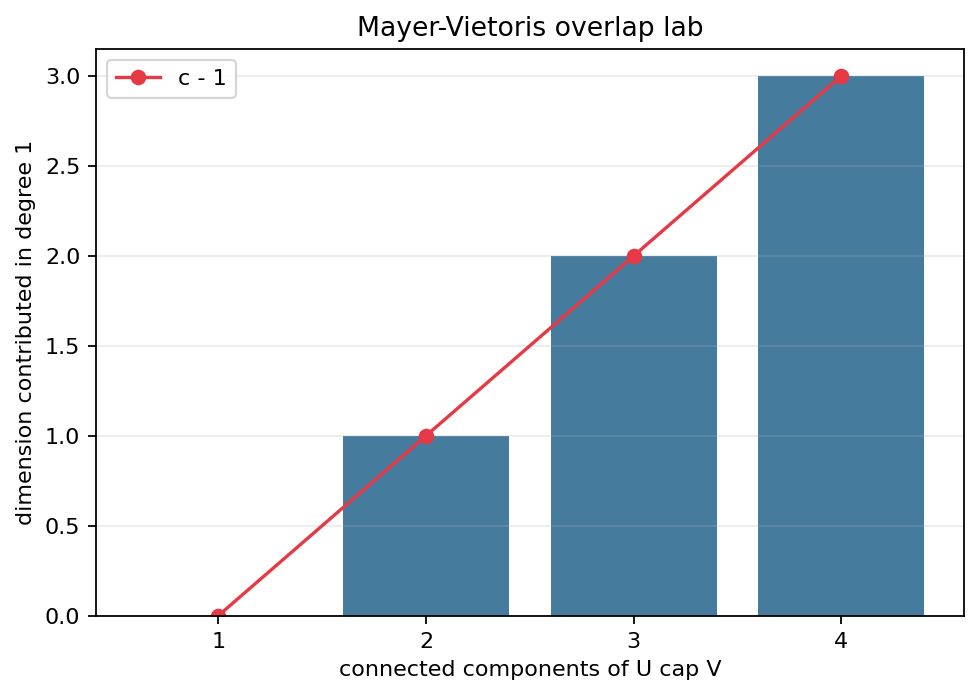

[mayer-vietoris-overlap-lab.csv](D:/Geometry/Differential-Forms-in-Algebraic-Topology/artifacts/chapter-01-de-rham-theory/tables/mayer-vietoris-overlap-lab.csv)

[{'overlap_components': 1,
  'rank_restriction_difference': 1,
  'computed_H1_dimension': 0,
  'matches_c_minus_1': True},
 {'overlap_components': 2,
  'rank_restriction_difference': 1,
  'computed_H1_dimension': 1,
  'matches_c_minus_1': True},
 {'overlap_components': 3,
  'rank_restriction_difference': 1,
  'computed_H1_dimension': 2,
  'matches_c_minus_1': True},
 {'overlap_components': 4,
  'rank_restriction_difference': 1,
  'computed_H1_dimension': 3,
  'matches_c_minus_1': True}]

In [10]:
def overlap_lab(overlap_components: int) -> dict[str, int | bool]:
    if overlap_components < 1:
        raise ValueError("overlap_components must be positive")
    Bc = np.tile(np.array([[-1.0, 1.0]]), (overlap_components, 1))
    image_dim = int(rank(Bc))
    h1_dim = int(overlap_components - image_dim)
    return {
        "overlap_components": overlap_components,
        "rank_restriction_difference": image_dim,
        "computed_H1_dimension": h1_dim,
        "matches_c_minus_1": bool(h1_dim == overlap_components - 1),
    }


lab_rows = [overlap_lab(c) for c in [1, 2, 3, 4]]
lab_table_path = save_csv(lab_rows, TABLES / "mayer-vietoris-overlap-lab.csv")
lab_report_path = save_json({"rows": lab_rows}, CHECKS / "mayer-vietoris-overlap-lab.json")

fig, ax = plt.subplots(figsize=(7.0, 4.6))
components = [row["overlap_components"] for row in lab_rows]
h1_dims = [row["computed_H1_dimension"] for row in lab_rows]
ax.bar(components, h1_dims, color="#457b9d")
ax.plot(components, [c - 1 for c in components], color="#e63946", marker="o", label="c - 1")
ax.set_xticks(components)
ax.set_xlabel("connected components of U cap V")
ax.set_ylabel("dimension contributed in degree 1")
ax.set_title("Mayer-Vietoris overlap lab")
ax.legend()
ax.grid(axis="y", alpha=0.25)
lab_fig_path = save_matplotlib(fig, FIGURES / "applied-lab-overlap-components.png")
plt.close(fig)

GENERATED_ARTIFACTS.extend([lab_table_path, lab_report_path, lab_fig_path])
display_artifact(lab_fig_path, width=720)
display_artifact(lab_table_path)
lab_rows


## Final Sanity Checks

The final cell treats the notebook as a small reproducible lab. It asserts that every chapter artifact exists, that PNGs are nonblank, and that the algebraic or geometric invariants computed above agree with the intended source concepts.


In [11]:
# final_sanity
from PIL import Image, ImageStat


def read_json(path: Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))


final_summary_path = save_json(
    {
        "unit": UNIT_TITLE,
        "source_span": "printed pages 13-88; physical PDF pages 24-99",
        "artifact_count_before_summary": len(GENERATED_ARTIFACTS),
        "artifact_paths": [path.relative_to(BOOK_ROOT).as_posix() for path in GENERATED_ARTIFACTS],
    },
    CHECKS / "final-sanity-summary.json",
)
all_artifacts = [*GENERATED_ARTIFACTS, final_summary_path]
assert_artifacts(all_artifacts, min_bytes=80)

png_paths = [path for path in all_artifacts if path.suffix.lower() == ".png"]
for path in png_paths:
    with Image.open(path) as image:
        image.load()
        stat = ImageStat.Stat(image.convert("RGB"))
        assert image.size[0] >= 400 and image.size[1] >= 300, (path, image.size)
        assert max(stat.stddev) > 1.0, f"blank-looking image: {path}"

symbolic = read_json(CHECKS / "de-rham-complex-symbolic-checks.json")
assert symbolic["d_squared_zero_for_function"]
assert symbolic["antiderivation_identity"]
assert symbolic["angular_form_closed_on_punctured_plane"]
assert abs(symbolic["angular_period_over_2pi"] - 1.0) < 1e-12

mv = read_json(CHECKS / "mayer-vietoris-s1-exactness.json")
assert mv["B_after_A_zero"] and mv["C_after_B_zero"]
assert mv["exact_at_H0_U_plus_V"] and mv["exact_at_H0_overlap"]
assert mv["computed_H1_S1_dimension"] == 1

stokes = read_json(CHECKS / "orientation-stokes-checks.json")
assert stokes["stokes_residual"] == "0"
assert stokes["boundary_integral"] == stokes["interior_integral"]

poincare = read_json(CHECKS / "poincare-compact-support-checks.json")
assert abs(poincare["mass_one_integral"] - 1.0) < 5e-4
assert abs(poincare["mass_one_primitive_right"] - 1.0) < 5e-4
assert abs(poincare["zero_mass_integral"]) < 5e-4
assert abs(poincare["zero_mass_primitive_right"]) < 5e-4

proof = read_json(CHECKS / "mv-argument-duality-dependency-graph.json")
assert proof["acyclic"] and proof["node_count"] >= 10

pd_check = read_json(CHECKS / "poincare-dual-torus-band.json")
assert abs(pd_check["horizontal_loop_integral"] - 1.0) < 5e-4
assert pd_check["vertical_loop_integral"] == 0.0

thom = read_json(CHECKS / "thom-fiber-integration-checks.json")
assert thom["fiber_mass_error"] < 1e-8
assert thom["projection_formula_residual_for_tau"] < 1e-8

nonorientable = read_json(CHECKS / "nonorientable-local-system-checks.json")
assert nonorientable["orientation_holonomy_mobius"] == -1
assert nonorientable["orientation_holonomy_cylinder"] == 1
assert nonorientable["density_integral_well_defined"]

lab = read_json(CHECKS / "mayer-vietoris-overlap-lab.json")
assert all(row["matches_c_minus_1"] for row in lab["rows"])
assert lab["rows"][1]["computed_H1_dimension"] == 1

print(f"final_sanity passed for {UNIT_TITLE}: {len(all_artifacts)} artifacts, {len(png_paths)} PNG checks")


final_sanity passed for De Rham Theory: 21 artifacts, 7 PNG checks


## Takeaways

- The de Rham complex turns calculus into cohomology because the exterior derivative squares to zero.
- Mayer-Vietoris is a computable exactness statement: overlap data becomes kernels, images, and connecting classes.
- Orientation is the sign structure that makes integration and Stokes' theorem invariant enough to define pairings.
- Compact support changes local cohomology; on `R`, total integral is the obstruction to a compactly supported primitive.
- Poincare duality is propagated by the Mayer-Vietoris argument and can be represented by forms localized in tubular neighborhoods.
- A Thom class is the vertical compact-support class with fiber integral one; it is the bundle version of a localized dual form.
- Nonorientable manifolds require the orientation local system or densities, because ordinary top forms cannot carry a global sign choice.
